In [1]:
francelink="https://docs.google.com/spreadsheets/d/e/2PACX-1vT7AaWf6Q0mu6aF1t9Bg5W8x70BJVVBGDXSm32KdwFVL_DqjwOJcAqdo2eZAjjZxM-oxKnodXc6kL0r/pub?gid=722617823&single=true&output=csv"
perulink="premierperu.csv"
import pandas as pd

pcm=pd.read_csv(perulink,parse_dates=['start','end'])
france=pd.read_csv(francelink)



In [2]:
pcm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Titular    232 non-null    object        
 1   Partido    166 non-null    object        
 2   Gobierno   232 non-null    object        
 3   Militar    169 non-null    float64       
 4   regime     231 non-null    object        
 5   Categoría  232 non-null    object        
 6   start      232 non-null    datetime64[ns]
 7   end        232 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(5)
memory usage: 14.6+ KB


In [3]:
pcm.head()

,Titular,Partido,Gobierno,Militar,regime,Categoría,start,end
0,José María Raygada y Gallo,Militar,Ramón Castilla (II),1.0,constitutional,FIN_GOBIERNO,1857-02-14,1858-05-13
1,Manuel Ortiz de Zevallos y García,NaN,Ramón Castilla (II),NaN,constitutional,CAMBIO_GABINETE,1858-05-13,1858-07-13
2,Miguel de San Román y Meza,Militar,Ramón Castilla (II),1.0,constitutional,CAMBIO_GABINETE,1858-07-13,1858-10-24
3,Miguel del Carpio y Melgar,NaN,Ramón Castilla (II),NaN,constitutional,CAMBIO_GABINETE,1858-10-28,1860-06-09
4,Juan Antonio Pezet Rodríguez,Militar,Ramón Castilla (II),1.0,constitutional,CAMBIO_GABINETE,1860-06-09,1862-01-01


In [4]:
pcm["Categoría"].value_counts()

Categoría
CAMBIO_GABINETE                           77
RENUNCIA_FORZADA                          39
TRANSICION                                26
RENUNCIA_VOLUNTARIA                       20
FIN_GOBIERNO                              16
GOLPE_ESTADO                              15
RENUNCIA                                  13
CENSURA_CONGRESO                          11
MUERTE                                     4
RENUNCIA_SALUD                             3
NEGACION_CONFIANZA                         3
REGIMEN_CAMBIA                             1
RENUNICA                                   1
RENUNICIA_FORZADA                          1
GOLPE_ESTADO/ RENUNCIA_VOLUNTARIA          1
CAMBIO_GABINETE / RENUNCIA_VOLUNTARIA      1
Name: count, dtype: int64

In [5]:
france.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        155 non-null    object
 1   Start Date  155 non-null    object
 2   End Date    155 non-null    object
 3   Republic    155 non-null    object
 4   Party       155 non-null    object
dtypes: object(5)
memory usage: 6.2+ KB


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Step 1: Prepare Peru data ---
pcm['start'] = pd.to_datetime(pcm['start'])
pcm['decade'] = (pcm['start'].dt.year // 10) * 10

peru_d = pcm.groupby('decade').size().reset_index(name='n')
peru_d['country'] = 'Peru'

# --- Step 2: Prepare France data ---
france['Start Date'] = pd.to_datetime(france['Start Date'])
france['decade'] = (france['Start Date'].dt.year // 10) * 10

france_d = france.groupby('decade').size().reset_index(name='n')
france_d['country'] = 'France'

# --- Step 3: Sanity check ---
print("Peru (pcm) total appointments:", len(pcm))
print("France total appointments:", len(france))
print("\nPeru by decade:\n", peru_d.to_string())
print("\nFrance by decade:\n", france_d.to_string())

Peru (pcm) total appointments: 232
France total appointments: 155

Peru by decade:
     decade   n country
0     1850   4    Peru
1     1860  20    Peru
2     1870  13    Peru
3     1880  21    Peru
4     1890  23    Peru
5     1900  13    Peru
6     1910  22    Peru
7     1920   4    Peru
8     1930  19    Peru
9     1940   6    Peru
10    1950   6    Peru
11    1960  10    Peru
12    1970   7    Peru
13    1980   9    Peru
14    1990  12    Peru
15    2000  10    Peru
16    2010  15    Peru
17    2020  18    Peru

France by decade:
     decade   n country
0     1840   5  France
1     1850   1  France
2     1870  14  France
3     1880  13  France
4     1890  12  France
5     1900   5  France
6     1910  12  France
7     1920  12  France
8     1930  20  France
9     1940  17  France
10    1950  16  France
11    1960   3  France
12    1970   3  France
13    1980   4  France
14    1990   5  France
15    2000   3  France
16    2010   4  France
17    2020   6  France


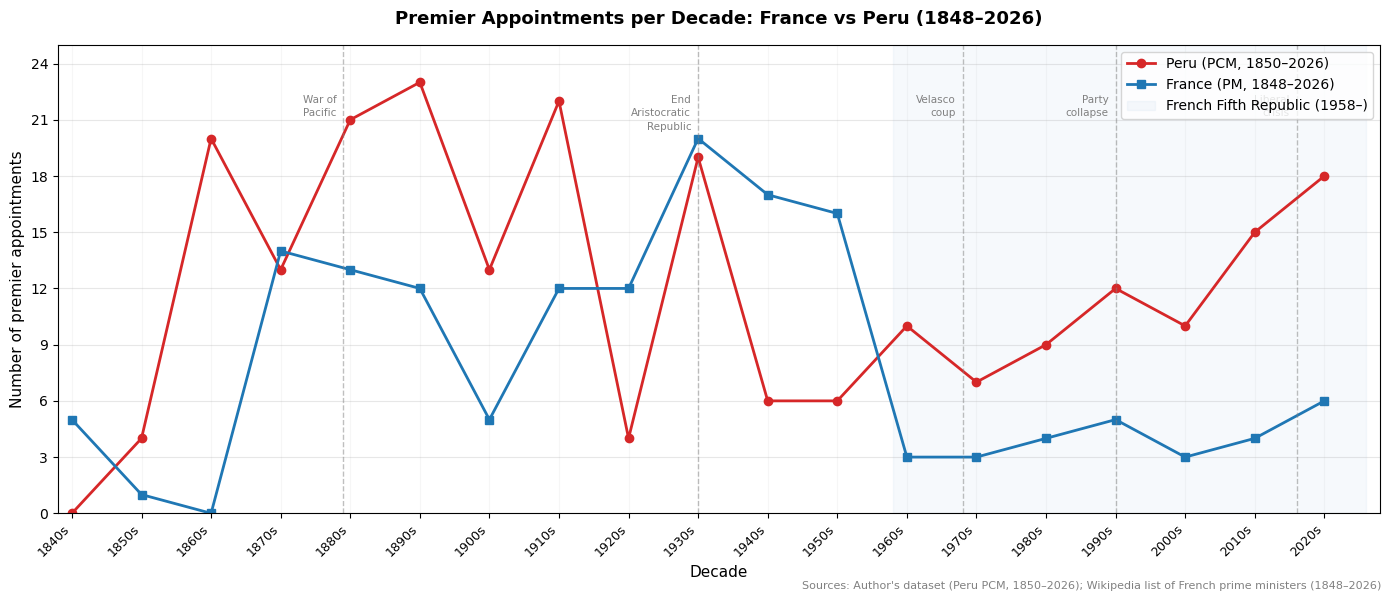

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Combine ---
combined = pd.concat([peru_d, france_d])
pivot = combined.pivot(index='decade', columns='country', values='n').fillna(0)
pivot = pivot[pivot.index >= 1840]

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(pivot.index, pivot['Peru'],
        color='#D62728', linewidth=2, marker='o',
        markersize=6, label='Peru (PCM, 1850–2026)')
ax.plot(pivot.index, pivot['France'],
        color='#1F77B4', linewidth=2, marker='s',
        markersize=6, label='France (PM, 1848–2026)')

# --- Epoch boundaries (Peru) ---
epoch_lines = {
    1879: 'War of\nPacific',
    1930: 'End\nAristocratic\nRepublic',
    1968: 'Velasco\ncoup',
    1990: 'Party\ncollapse',
    2016: 'Liberal\ncrisis'
}

ymax = combined['n'].max()
for year, label in epoch_lines.items():
    ax.axvline(x=year, color='grey', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(year - 1, ymax * 0.97, label,
            fontsize=7.5, color='grey', ha='right',
            va='top', linespacing=1.4)

# --- Shade Fifth Republic stabilization ---
ax.axvspan(1958, 2026, alpha=0.04, color='#1F77B4',
           label='French Fifth Republic (1958–)')

# --- Formatting ---
ax.set_xticks(range(1840, 2030, 10))
ax.set_xticklabels(
    [f"{y}s" for y in range(1840, 2030, 10)],
    rotation=45, ha='right', fontsize=9
)
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('Number of premier appointments', fontsize=11)
ax.set_title(
    'Premier Appointments per Decade: France vs Peru (1848–2026)',
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(loc='upper right', fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3)
ax.grid(axis='x', alpha=0.1)
ax.set_xlim(1838, 2028)
ax.set_ylim(0, ymax + 2)

plt.figtext(
    0.99, 0.01,
    'Sources: Author\'s dataset (Peru PCM, 1850–2026); '
    'Wikipedia list of French prime ministers (1848–2026)',
    ha='right', fontsize=8, color='grey'
)

plt.tight_layout()
plt.savefig('premiers_decennial.pdf', dpi=300, bbox_inches='tight')
plt.savefig('premiers_decennial.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
pcm.columns

Index(['Unnamed: 0', 'Titular', 'Partido', 'Gobierno', 'Inicio', 'Fin',
       'start', 'end', 'Militar', 'regime', 'Trust', 'obs', 'Razón de Salida',
       'Categoría', 'Notas / Contexto Histórico', 'decade', 'duration_days'],
      dtype='object')

In [27]:
whichcols=['Titular', 
       'start', 'end', 'Militar', 'regime', 'Trust',  
       'Categoría','duration_days']

# Longest and shortest PCM spells (excluding zeros)
pcm['duration_days'] = (pcm['end'] - pcm['start']).dt.days

longest = pcm[pcm['duration_days'] > 0].nlargest(5, 'duration_days')[whichcols]

shortest = pcm[pcm['duration_days'] > 0].nsmallest(5, 'duration_days')[whichcols]

print("LONGEST:\n", longest.to_string())
print("\nSHORTEST:\n", shortest.to_string())

LONGEST:
                        Titular      start        end  Militar          regime Trust        Categoría  duration_days
138        Alfredo Solf y Muro 1939-12-08 1944-12-03      NaN  constitutional     1     FIN_GOBIERNO           1822
160   Ernesto Montagne Sánchez 1968-10-03 1973-01-31      1.0         deFacto     1  CAMBIO_GABINETE           1581
145       Zenón Noriega Agüero 1950-07-28 1954-08-09      1.0  constitutional     1  CAMBIO_GABINETE           1473
136  Ernesto Montagne Markholz 1936-04-13 1939-04-19      1.0      Provisorio     1     FIN_GOBIERNO           1101
89              Augusto Leguía 1904-09-24 1907-08-01      0.0  constitutional     1     FIN_GOBIERNO           1041

SHORTEST:
                          Titular      start        end  Militar          regime Trust         Categoría  duration_days
120   Fernando Sarmiento Ramírez 1930-08-24 1930-08-25      1.0  constitutional     0      GOLPE_ESTADO              1
159          Miguel Mujica Gallo 1968-10-02 